In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [32]:
data = pd.read_csv('data (1).csv')
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True, errors='ignore')


if 'diagnosis' in data.columns:
    data.drop(['diagnosis'], axis=1, inplace=True)

print(" Data Loaded and Labels Dropped")
print(f"Data Shape: {data.shape}")

 Data Loaded and Labels Dropped
Data Shape: (569, 30)


In [33]:
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)


In [34]:
train_data, temp_data = train_test_split(data_scaled, test_size=0.7, random_state=42)
test1_data, test2_data = train_test_split(temp_data, test_size=0.5, random_state=42)

In [35]:
print("\n Data Split Completed:")
print(f"Train Data: {train_data.shape}")
print(f"Test1 Data: {test1_data.shape}")
print(f"Test2 Data: {test2_data.shape}")


 Data Split Completed:
Train Data: (170, 30)
Test1 Data: (199, 30)
Test2 Data: (200, 30)


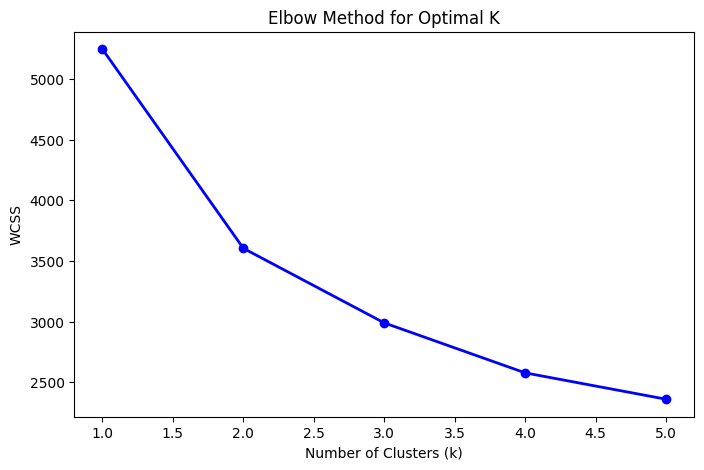

In [36]:
wcss = []
K = range(1, 6)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(train_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, wcss, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

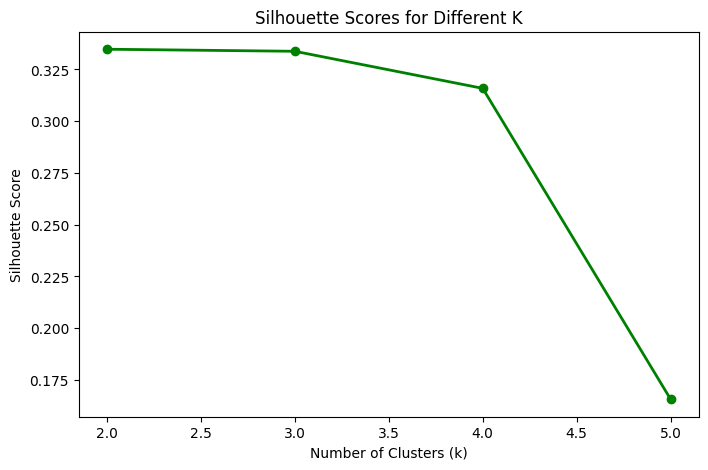


 Best K based on Silhouette Score: 2


In [37]:
sil_scores = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(train_data)
    sil_scores.append(silhouette_score(train_data, kmeans.labels_))

plt.figure(figsize=(8,5))
plt.plot(range(2, 6), sil_scores, 'go-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K')
plt.show()
best_k = np.argmax(sil_scores) + 2
print(f"\n Best K based on Silhouette Score: {best_k}")


In [38]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(train_data)

train_preds = kmeans_final.predict(train_data)
test1_preds = kmeans_final.predict(test1_data)
test2_preds = kmeans_final.predict(test2_data)

print("\nCluster Counts:")
print("Train:", np.bincount(train_preds))
print("Test1:", np.bincount(test1_preds))
print("Test2:", np.bincount(test2_preds))


Cluster Counts:
Train: [109  61]
Test1: [122  77]
Test2: [147  53]


In [39]:
from sklearn.manifold import TSNE


In [40]:

tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1500)
train_tsne = tsne.fit_transform(train_data)


test1_tsne = tsne.fit_transform(test1_data)


test2_tsne = tsne.fit_transform(test2_data)


C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


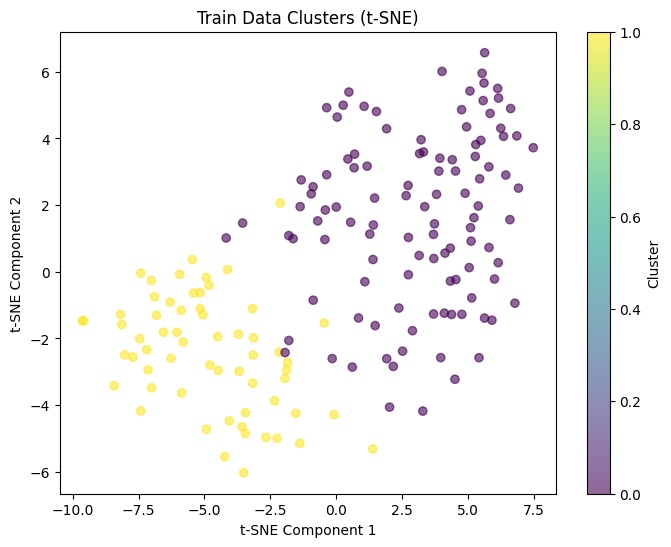

In [62]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))
plt.scatter(train_tsne[:,0], train_tsne[:,1], c=train_preds, cmap='viridis', alpha=0.6)
plt.title('Train Data Clusters (t-SNE)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Cluster')
plt.show()




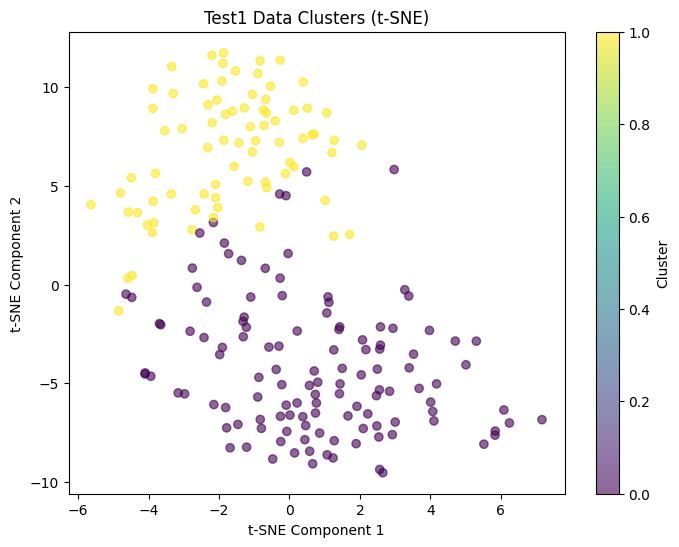

In [63]:
plt.figure(figsize=(8,6))
plt.scatter(test1_tsne[:,0], test1_tsne[:,1], c=test1_preds, cmap='viridis', alpha=0.6)
plt.title('Test1 Data Clusters (t-SNE)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Cluster')
plt.show()



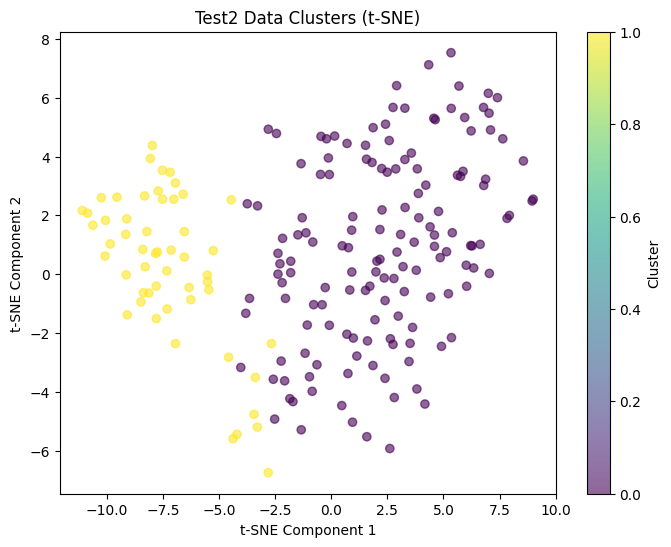

In [64]:
plt.figure(figsize=(8,6))
plt.scatter(test2_tsne[:,0], test2_tsne[:,1], c=test2_preds, cmap='viridis', alpha=0.6)
plt.title('Test2 Data Clusters (t-SNE)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Cluster')
plt.show()


In [66]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

def visualize_tsne(data, labels, title):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    tsne_data = tsne.fit_transform(data)
    plt.figure(figsize=(8,6))
    plt.scatter(tsne_data[:,0], tsne_data[:,1], c=labels, cmap='viridis', alpha=0.6)
    plt.title(title)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.colorbar(label="Cluster")
    plt.show()

datasets = [("Train", train_data), ("Test1", test1_data), ("Test2", test2_data)]



C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


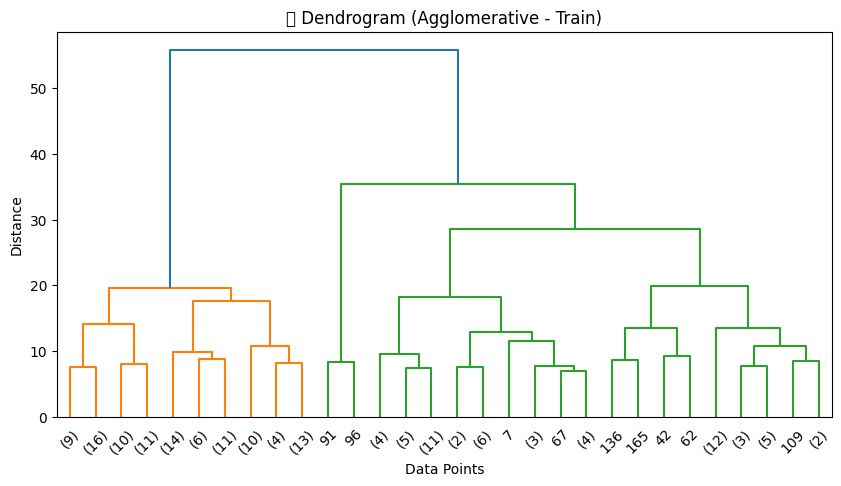

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


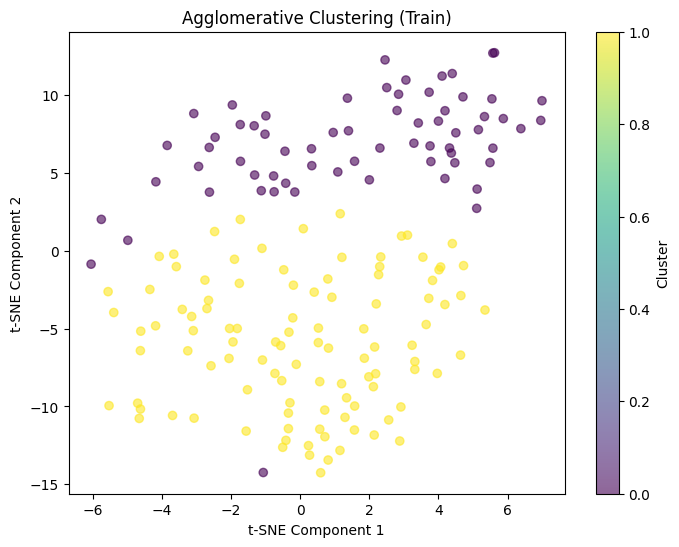

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


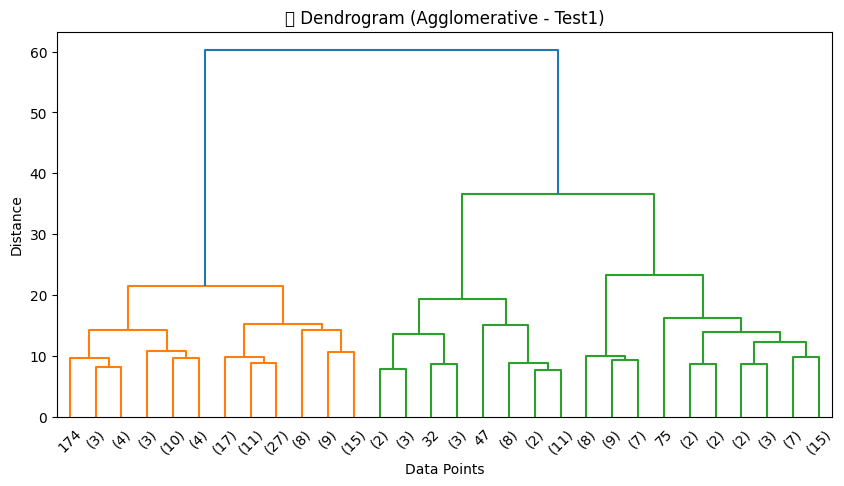

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


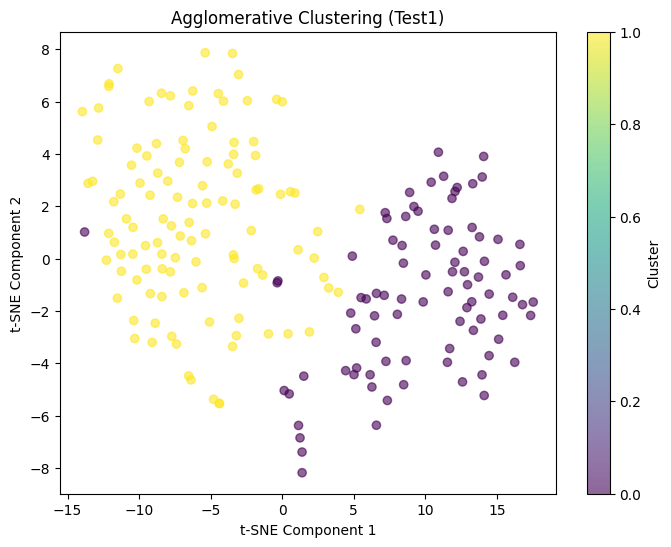

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


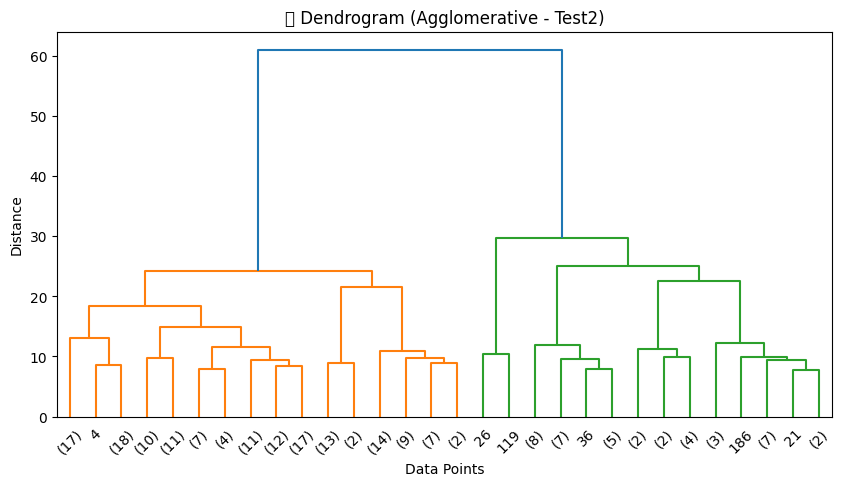

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


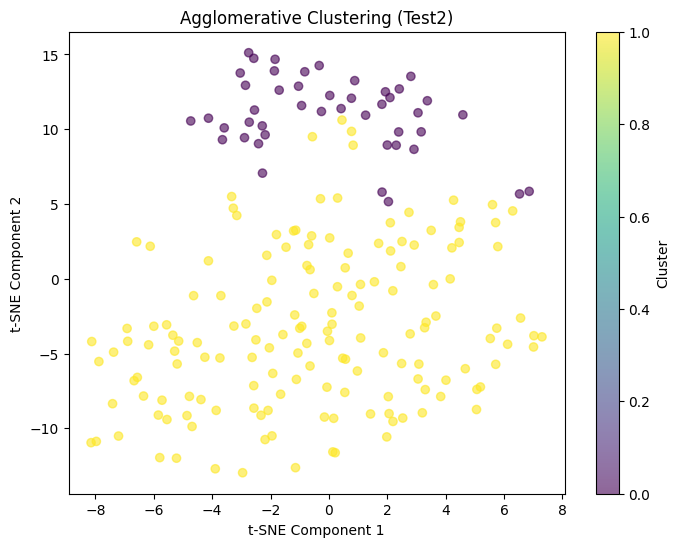

In [67]:
agglo_labels = {}
for name, data in datasets:
    agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
    labels = agglo.fit_predict(data)
    agglo_labels[name] = labels

    
    plt.figure(figsize=(10,5))
    linked = linkage(data, method='ward')
    dendrogram(linked, truncate_mode='lastp', p=30)
    plt.title(f" Dendrogram (Agglomerative - {name})")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()

   
    visualize_tsne(data, labels, f"Agglomerative Clustering ({name})")



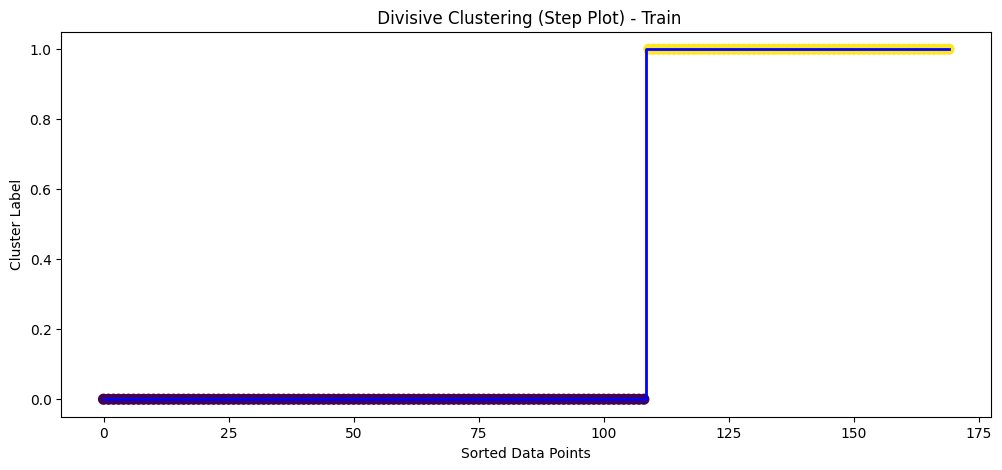

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


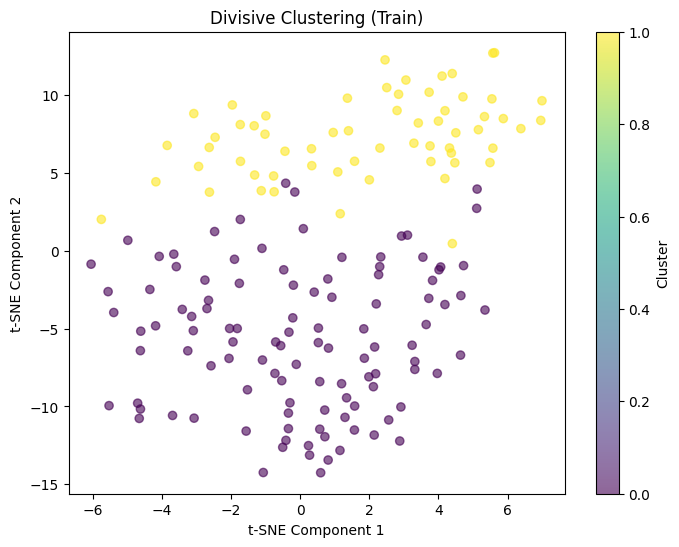

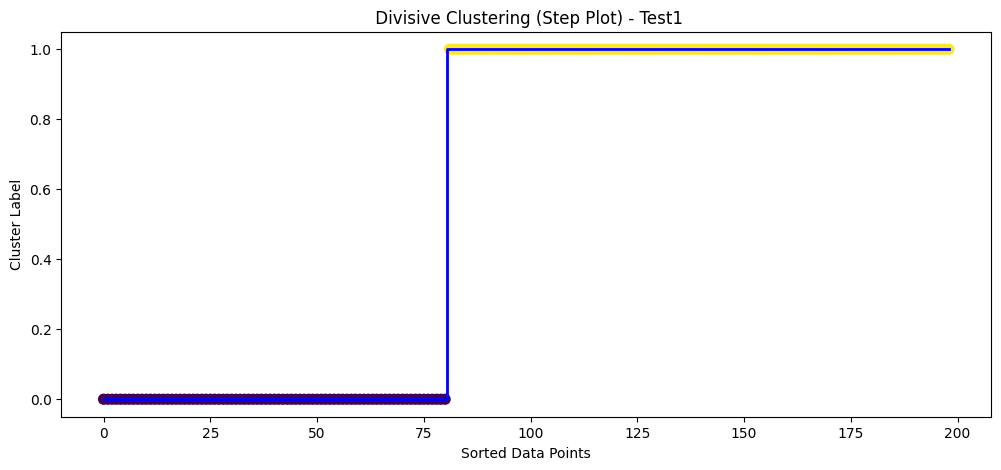

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


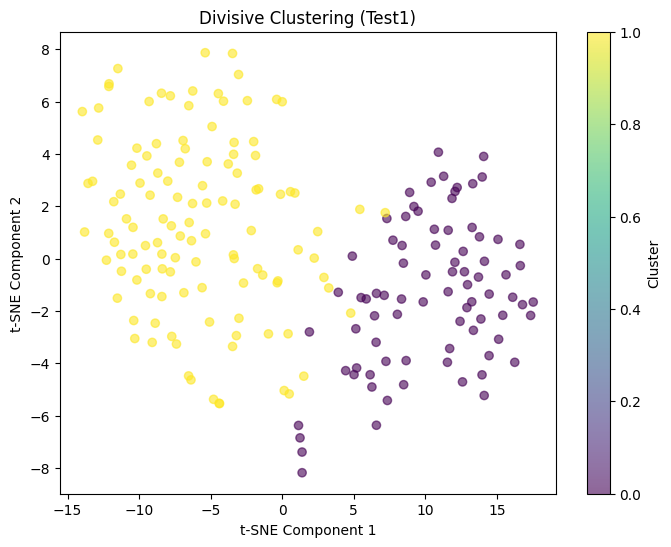

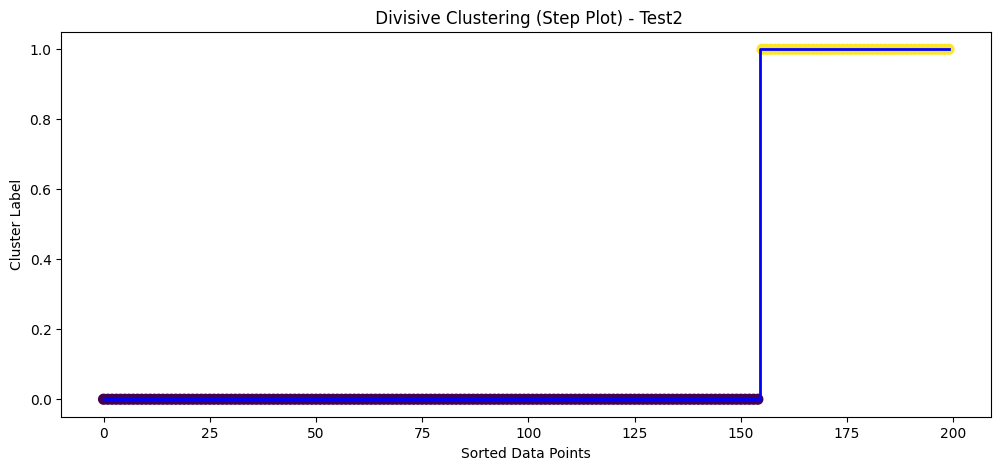

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


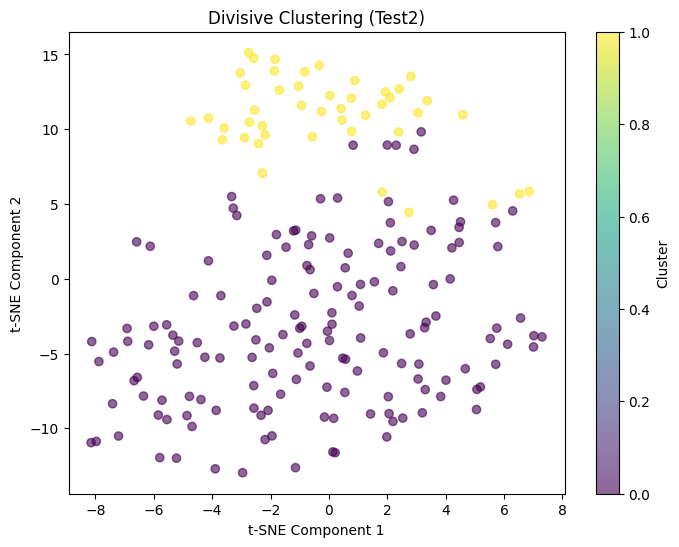

In [68]:



divisive_labels = {}
for name, data in datasets:
    # Perform bisecting KMeans (2 clusters)
    km = KMeans(n_clusters=2, random_state=42)
    labels = km.fit_predict(data)
    divisive_labels[name] = labels

    # Step plot to mimic dendrogram
    plt.figure(figsize=(12,5))
    plt.title(f" Divisive Clustering (Step Plot) - {name}")
    plt.xlabel("Sorted Data Points")
    plt.ylabel("Cluster Label")
    plt.step(np.arange(len(labels)), np.sort(labels), where='mid', color='blue', linewidth=2)
    plt.scatter(np.arange(len(labels)), np.sort(labels), c=np.sort(labels), cmap='viridis', s=50)
    plt.show()

    # t-SNE
    visualize_tsne(data, labels, f"Divisive Clustering ({name})")

# ======================================================
# 🔹 GAUSSIAN MIXTURE MODEL (Expectation-Maximization)
# ======================================================




C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


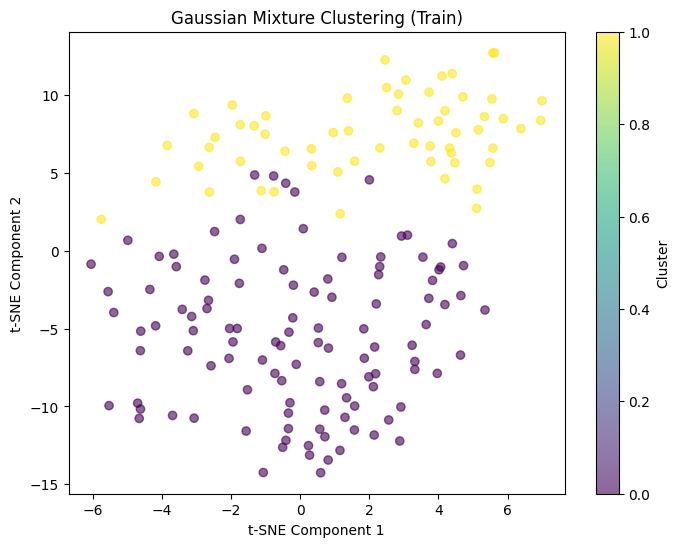

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


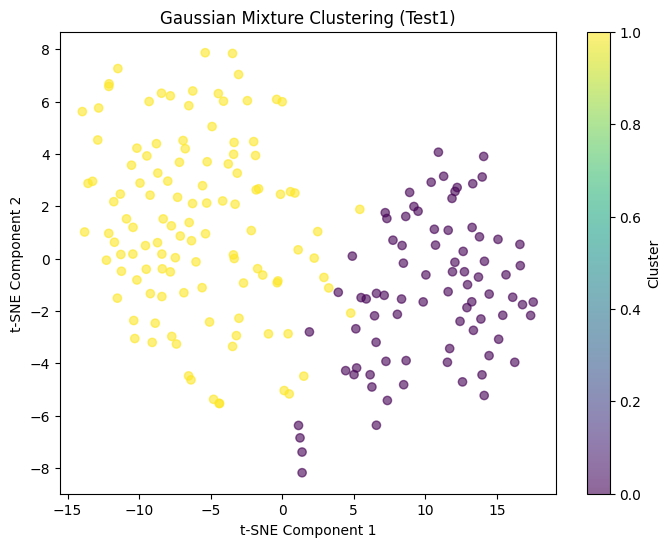

C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


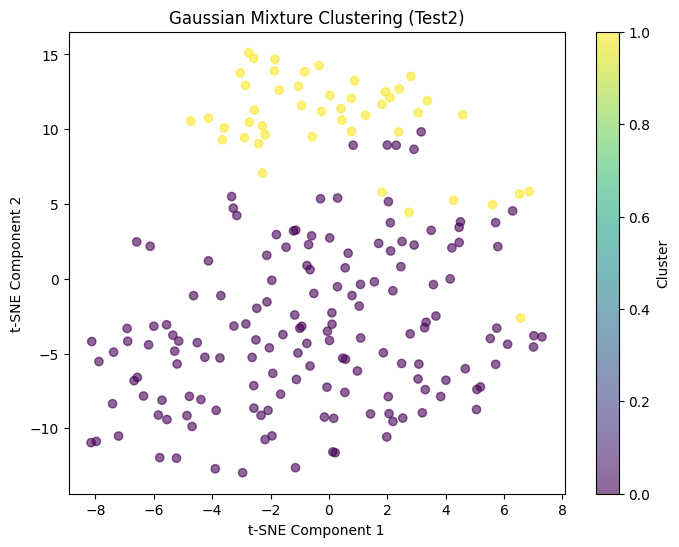

In [69]:
gmm_labels = {}
for name, data in datasets:
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
    gmm.fit(data)
    labels = gmm.predict(data)
    gmm_labels[name] = labels

    # t-SNE
    visualize_tsne(data, labels, f"Gaussian Mixture Clustering ({name})")


C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed

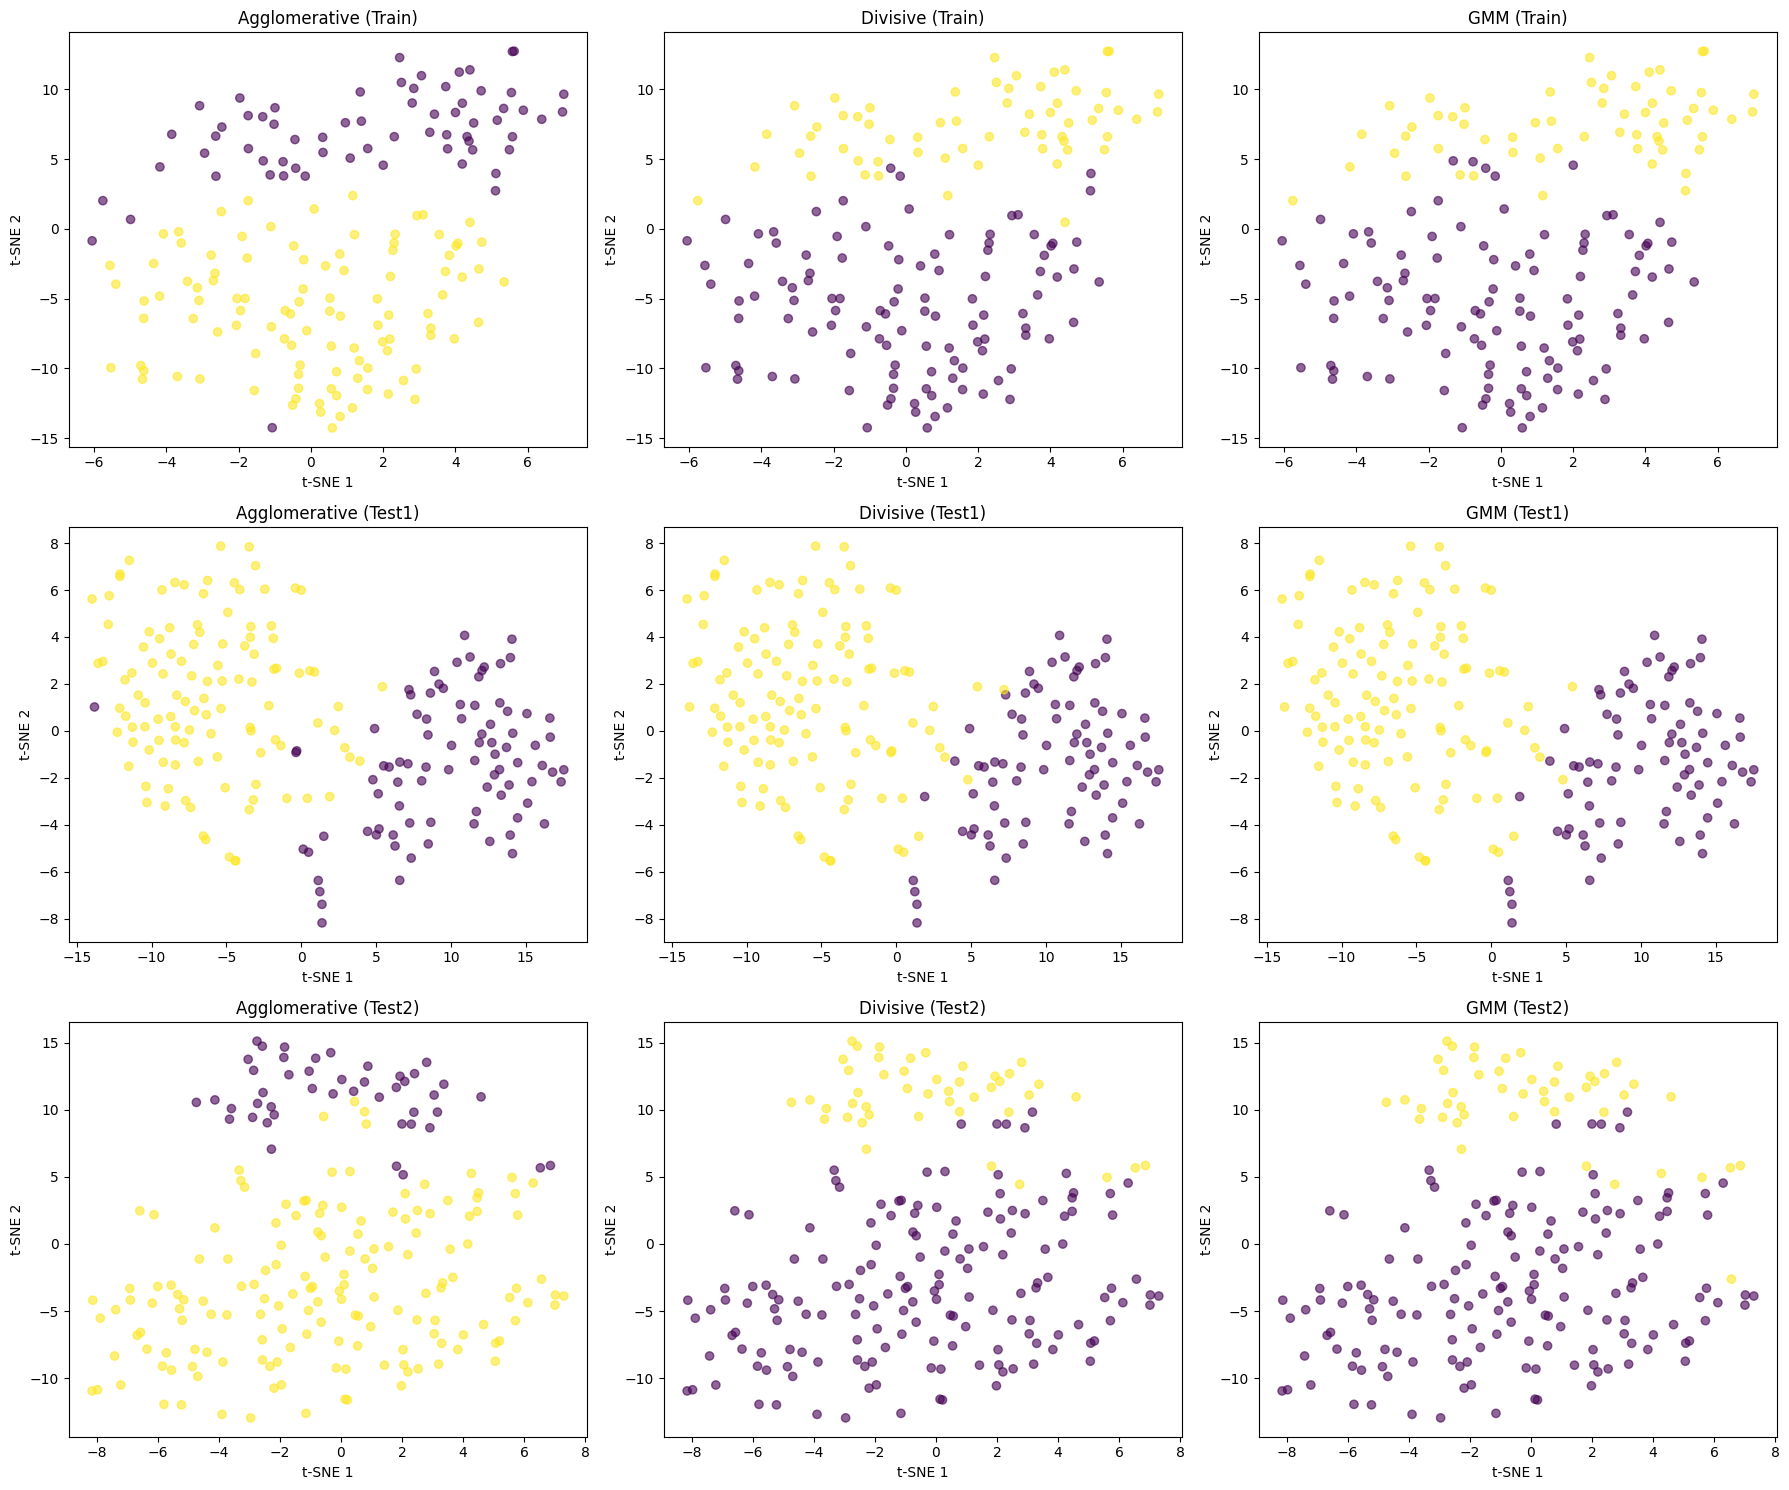

In [ ]:


import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


all_labels = {
    "Agglomerative": agglo_labels,
    "Divisive": divisive_labels,
    "GMM": gmm_labels
}

methods = ["Agglomerative", "Divisive", "GMM"]
datasets_names = ["Train", "Test1", "Test2"]

plt.figure(figsize=(18, 15))  

for i, dataset_name in enumerate(datasets_names):
    for j, method in enumerate(methods):
        labels = all_labels[method][dataset_name]
        data = dict(datasets)[dataset_name]

       
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
        tsne_data = tsne.fit_transform(data)

        
        plt.subplot(3, 3, i*3 + j + 1)
        plt.scatter(tsne_data[:,0], tsne_data[:,1], c=labels, cmap='viridis', alpha=0.6)
        plt.title(f"{method} ({dataset_name})")
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")

plt.tight_layout()
plt.show()
